#### K-Nearest Neighbour Algorithm - Ued for Regression and Classification(mostly)
#### Non Parametric Algo means does not make any assumptions called lazy learner algo

##### Manhattan Distance L1 = |X2-X1|+|Y2-Y1|
##### Euclidean Distance L2 = Root(X2-X1)2+(Y2-Y1)2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

In [2]:
dataset = pd.read_csv("social_ads_generated.csv")
dataset.head(3)

,Age,Salary,Purchased
0,26,90083,1
1,42,113082,0
2,21,130449,0


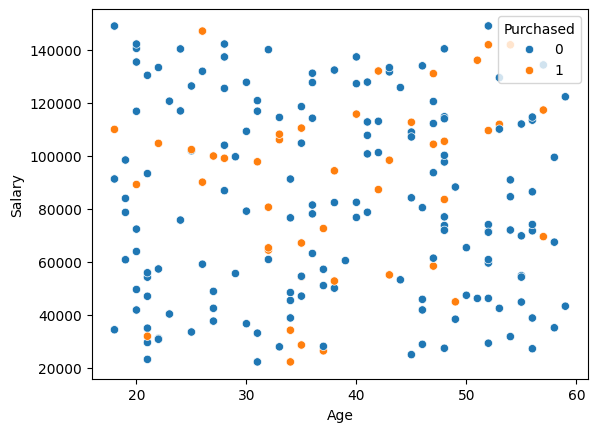

In [5]:
sns.scatterplot(data=dataset, x="Age", y="Salary", hue="Purchased")
plt.show()

In [22]:
x = dataset.iloc[:, :-1]
y =dataset["Purchased"]

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
sc = StandardScaler()
x_scaled = sc.fit_transform(x)

In [25]:
x = pd.DataFrame(x_scaled, columns=["Age", "Salary"])

In [26]:
x

,Age,Salary
0,-1.008092,0.179123
1,0.322723,0.825210
2,-1.423972,1.313083
3,1.570361,0.944601
4,0.239547,0.818299
...,...,...
195,1.487185,-0.269815
196,-0.758564,-0.790218
197,0.738602,-0.627481
198,1.320833,1.636927


In [27]:
from sklearn.model_selection import train_test_split


In [28]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)   

In [29]:
# Since dataset is classification, we will use KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Defualt is Euclidean distance but for Manhattan distance, we can use p=1
knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(x_train, y_train)

,n_neighbors,8
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [52]:
knn.score(x_test, y_test)*100

77.5

##### Lets check for overfitting that is diff in trainig and testing


In [53]:
knn.score(x_train, y_train)*100

78.125

In [45]:
# Lets check the overfitting by using loop
for i in range(1, 30):
    knn1 = KNeighborsClassifier(n_neighbors=i)
    knn1.fit(x_train, y_train)
    print(f"Neighbors: {i}, Train Score: {knn1.score(x_train, y_train)*100}, Test Score: {knn1.score(x_test, y_test)*100}")

Neighbors: 1, Train Score: 100.0, Test Score: 70.0
Neighbors: 2, Train Score: 82.5, Test Score: 80.0
Neighbors: 3, Train Score: 84.375, Test Score: 77.5
Neighbors: 4, Train Score: 79.375, Test Score: 80.0
Neighbors: 5, Train Score: 79.375, Test Score: 77.5
Neighbors: 6, Train Score: 78.125, Test Score: 75.0
Neighbors: 7, Train Score: 78.75, Test Score: 77.5
Neighbors: 8, Train Score: 76.25, Test Score: 77.5
Neighbors: 9, Train Score: 78.125, Test Score: 75.0
Neighbors: 10, Train Score: 78.75, Test Score: 80.0
Neighbors: 11, Train Score: 81.25, Test Score: 80.0
Neighbors: 12, Train Score: 78.125, Test Score: 82.5
Neighbors: 13, Train Score: 77.5, Test Score: 82.5
Neighbors: 14, Train Score: 76.25, Test Score: 82.5
Neighbors: 15, Train Score: 76.875, Test Score: 82.5
Neighbors: 16, Train Score: 76.25, Test Score: 82.5
Neighbors: 17, Train Score: 76.875, Test Score: 82.5
Neighbors: 18, Train Score: 77.5, Test Score: 82.5
Neighbors: 19, Train Score: 76.875, Test Score: 82.5
Neighbors: 20, 

##### According to this data we take neighbor value here it is 7 or 8 n_neighbors = 7 or 8

In [ ]:
# Now lets predict for new data(from scaled data )
knn.predict([[0.322723,0.825210]])

c:\Users\sures\OneDrive\Desktop\python\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0])

c:\Users\sures\OneDrive\Desktop\python\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


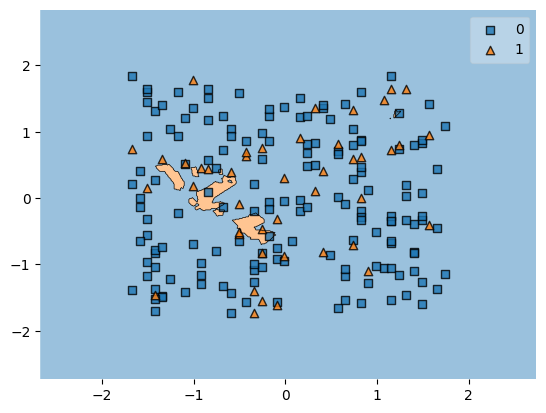

In [50]:
plot_decision_regions(np.array(x), np.array(y), clf=knn)
plt.show()